In [1]:
################# Plot Vorticity - Strain PDF ############################
# The purpose of this script is to calculate and plot a PDF of 
# vorticity and strain for a given ROMS output to see if it looks
# like what we would expect or not.
#
# Notes: 
# - This script runs in xroms
# - This script heavily uses code from Dylan Schlichting 
#   - Specifically from: https://github.com/dylanschlichting/beaufort_roms/blob/main/plotting_examples/invariant_pdfs.ipynb
#
##########################################################################

In [20]:
# Load in the packages
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as tick
import numpy as np
import xarray as xr
import pandas as pd
import xroms
import cartopy
from matplotlib.colors import BoundaryNorm
import cmocean.cm as cmo
import xarray as xr
from netCDF4 import Dataset
# from mpas_analysis.shared.io.utility import decode_strings
from glob import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
from matplotlib import ticker
from xhistogram.xarray import histogram
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext

import warnings 
warnings.filterwarnings("ignore") #turns off annoying warnings

In [3]:
# Define a function to load in the output
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [4]:
def add_derivatives(ds, grid, q='salt'):
    '''
Analysis of velocity gradient tensor and frontogenesis function
following Hetland et al. (2025) JPO. 
https://journals.ametsoc.org/view/journals/phoc/aop/JPO-D-24-0060.1/JPO-D-24-0060.1.xml

Properties computed at the top vertical level, i.e., at the ocean surface.

    '''
    qs = ds[q]
    
    #############################
    # Flow and property gradients at the ocean surface
    
    ds['dqdx'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'X'), grid)    # defined at rho-points
    ds['dqdy'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'Y'), grid)    # defined at rho-points
    
    ds['dudx'] = grid.derivative(ds.isel(s_rho=-1).u, 'X', boundary='extend')  # defined at rho-points
    ds['dvdy'] = grid.derivative(ds.isel(s_rho=-1).v, 'Y', boundary='extend')  # defined at rho-points
    ds['dvdx'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).v, 'X', boundary='extend'), grid)  # defined at rho-points
    ds['dudy'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).u, 'Y', boundary='extend'), grid)  # defined at rho-points
    
    ###########################
    # Invariant flow properties
    
    # Vorticity:  v_x - u_y
    ds['zeta'] = (ds.dvdx - ds.dudy)/ds.f
    ds['zeta'].name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    ds['delta'] = (ds.dudx + ds.dvdy)/ds.f
    ds['delta'].name = 'Normalized divergence'

    # Major axis of deformation
    ds['sigma'] = ( np.sqrt( (ds.dudx-ds.dvdy)**2 + (ds.dvdx+ds.dudy)**2 ) )/ds.f
    ds['sigma'].name = 'Normalized total strain'

    ##################################
    # Principle deformation components

    ds['lminor'] = 0.5 * (ds.delta - ds.sigma)
    ds['lminor'].name = 'lambda minor'

    ds['lmajor'] = 0.5 * (ds.delta + ds.sigma)
    ds['lmajor'].name = 'lambda major'
    
    #############################################
    # Along- and cross-frontal velocity gradients
    
    # angle is wrt x, so need to do arctan2(y, x)
    ds['phi_cf'] = np.arctan2(ds.dqdy, ds.dqdx)
    ds['phi_af'] = ds.phi_cf + np.pi/2.0

    ds['du_cf'] = ( ds.dudx*np.cos(ds.phi_cf)**2 + ds.dvdy*np.sin(ds.phi_cf)**2 
               + (ds.dudy + ds.dvdx)*np.sin(ds.phi_cf)*np.cos(ds.phi_cf) )/ds.f

    ds['du_af'] = ( ds.dudx*np.cos(ds.phi_af)**2 + ds.dvdy*np.sin(ds.phi_af)**2
              + (ds.dudy + ds.dvdx)*np.sin(ds.phi_af)*np.cos(ds.phi_af) )/ds.f
    
    ############################
    # The frontogenesis function
    
    # Dimensional frontogenesis function
    Dgradq_i = - ds.dudx*ds.dqdx - ds.dvdx*ds.dqdy
    Dgradq_j = - ds.dudy*ds.dqdx - ds.dvdy*ds.dqdy
    ds['Ddelq2'] = (ds.dqdx*Dgradq_i + ds.dqdy*Dgradq_j)
    ds['Ddelq2'].name = 'Frontogenesis function'

    # Density gradients squared
    ds['gradq2'] = ds.dqdx**2 + ds.dqdy**2
    ds['gradq2'].name = r'$(\nabla q)^2$'

    # Normalized frontogenesis function
    ds['nFGF'] = 0.5 * ds.Ddelq2 / (ds.gradq2 * ds.f)
    ds['nFGF'].name = r'Normalized Frontogenesis Function'
    
    return ds

### Load in the Output


In [5]:
# Load in the model output

# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps, grid_u3c4_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'))
add_derivatives(ds_ice_u3c4_keps, grid_u3c4_keps)
# Constant forcing, u3c4, k-epsilon
# ds_ice_u3c4_keps_no_ice, grid_u3c4_keps_no_ice = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_no_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'))
# # Constant forcing, U3C4, gen
# ds_ice_u3c4_gen, grid_u3c4_gen = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc'))
# # Constant forcing, U3C4, kkl
# ds_ice_u3c4_kkl, grid_u3c4_kkl = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc'))
# # Constant forcing, U3C4, k-omega
# ds_ice_u3c4_komega, grid_u3c4_komega = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc'))
# # Constant forcing, U3C4, kpp
# ds_ice_u3c4_kpp, grid_u3c4_kpp = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc'))
# # Constant forcing, akima, k-epsilon
# ds_ice_akima_keps, grid_akima_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_akima_keps_*.nc'))
# # Constant forcing, HSIMT, k-epsilon
# ds_ice_hsimt_kep, grid_hsimt_kepss = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_HSIMT_keps_*.nc'))
# # Constant forcing, MPDATA, k-epsilon
# ds_ice_mpdata_keps, grid_mpdata_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_mpdata_keps_*.nc'))
# # Constant forcing, u3splitc4, k-epsilon
# ds_ice_u3splitc4_keps, grid_u3splitc4_keps = open_mfroms(glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3splitc4_keps_*.nc'))


<xarray.Dataset> Size: 6TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1440)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 190GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 190GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 185GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/168)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Thursday - January 1, 2026 -  7:17:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

### Process the Output  
I think we only want to do this for one run for now so do U3C4, k-epsilon

In [6]:
# Make things for plotting 

# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds_ice_u3c4_keps.x_rho[0,2].values - ds_ice_u3c4_keps.x_rho[0,1].values
print('dx: ', dx)
dy = ds_ice_u3c4_keps.y_rho[1,0].values - ds_ice_u3c4_keps.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds_ice_u3c4_keps.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds_ice_u3c4_keps.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds_ice.x_rho: ', ds_ice_u3c4_keps.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds_ice_u3c4_keps.y_rho: ', ds_ice_u3c4_keps.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds_ice.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds_ice_u3c4_keps.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


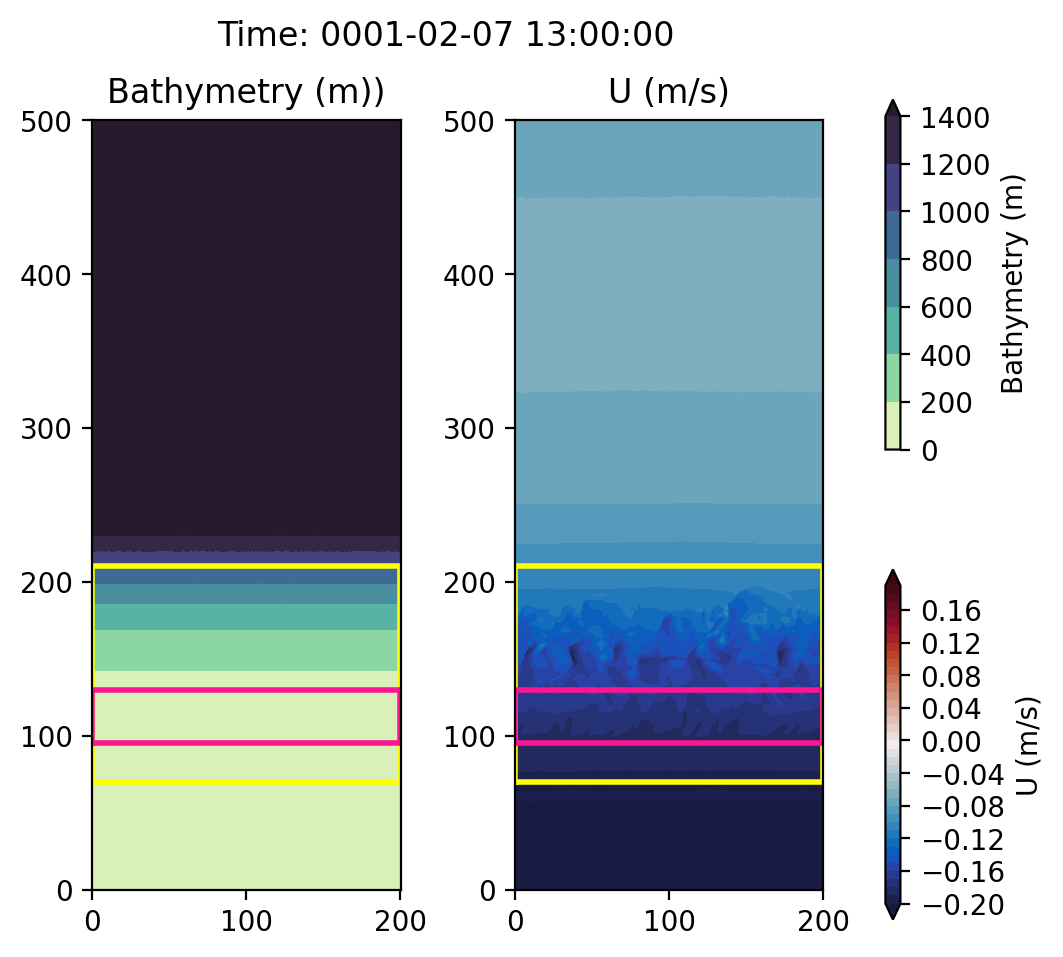

In [7]:
# Plot the region we are looking over and set the slices

# Plot the domain to make sure we have the right area

# Plot the domain to figure out where we want to take the 
# average in the horizontal 

# Set the time index
time_idx1 = 450

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)
lev_u = np.arange(-0.2, 0.2, 0.01)

# Make the figure 
fig, ax = plt.subplots(1, 2, figsize=(5,5), dpi=200)

# Plot bathymetry
cs1 = ax[0].contourf(x_rho/1000, y_rho/1000, ds_ice_u3c4_keps.h[:,:], cmap=cmo.deep,
                     extend='max')
ax[0].set_title('Bathymetry (m))')
# Make a colorbar 
cbar_ax1 = fig.add_axes([0.94,0.55,0.015,0.35])
fig.colorbar(cs1,ax=ax,extend='both',
             label='Bathymetry (m)',
             pad=0.03, cax=cbar_ax1)

# Plot surface u
cs2 = ax[1].contourf(x_u/1000, y_u/1000, ds_ice_u3c4_keps.u[time_idx1,-1,:,:], 
                     lev_u, cmap=cmo.balance, extend='both')
ax[1].set_title('U (m/s)')
# Make a colorbar 
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(cs2,ax=ax,extend='both',
             label='U (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set aspect ratio
    ax[r].set_aspect(1.0)

# Add the time
fig.suptitle('Time: ' + str(ds_ice_u3c4_keps.ocean_time[time_idx1].values)[0:19])

# Pick a region to analyze 
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
# Plot Box 1
ax[0].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)

# Box 2
box_min_x_02 = 0
box_max_x_02 = 200
box_min_y_02 = (190*dy)/1000
box_max_y_02 = (260*dx)/1000
# Plot Box 1
ax[0].plot([box_min_x_02, box_max_x_02, box_max_x_02, box_min_x_02, box_min_x_02],
        [box_min_y_02, box_min_y_02, box_max_y_02, box_max_y_02, box_min_y_02],
        color='deeppink', linestyle='-', linewidth=2)
ax[1].plot([box_min_x_02, box_max_x_02, box_max_x_02, box_min_x_02, box_min_x_02],
        [box_min_y_02, box_min_y_02, box_max_y_02, box_max_y_02, box_min_y_02],
        color='deeppink', linestyle='-', linewidth=2)

fig.canvas.draw()

In [8]:
# Find where these regions are in terms of xi and eta slicing 
# Becuase of periodic boundaries, we want the second to last 
# xi idx and to start at 1 and not 0
box_min_x_01_idx = ((box_min_x_01 * 1000)+dx)/dx
print('box_min_x_01_idx: ', box_min_x_01_idx)
box_max_x_01_idx = ((box_max_x_01 * 1000)-dx)/dx
print('box_max_x_01_idx: ', box_max_x_01_idx)
box_min_y_01_idx = (box_min_y_01 * 1000)/dy
print('box_min_y_01_idx: ', box_min_y_01_idx)
box_max_y_01_idx = (box_max_y_01 * 1000)/dy
print('box_max_y_01_idx: ', box_max_y_01_idx)

xi_slice = slice(int(box_min_x_01_idx), int(box_max_x_01_idx))
eta_slice_box1 = slice(int(box_min_y_01_idx), int(box_max_y_01_idx))

# Box 2
box_min_x_02_idx = ((box_min_x_02 * 1000)+dx)/dx
print('box_min_x_02_idx: ', box_min_x_02_idx)
box_max_x_02_idx = ((box_max_x_02 * 1000)-dx)/dx
print('box_max_x_02_idx: ', box_max_x_02_idx)
box_min_y_02_idx = (box_min_y_02 * 1000)/dy
print('box_min_y_02_idx: ', box_min_y_02_idx)
box_max_y_02_idx = (box_max_y_02 * 1000)/dy
print('box_max_y_02_idx: ', box_max_y_02_idx)

eta_slice_box2 = slice(190,260)

box_min_x_01_idx:  1.0
box_max_x_01_idx:  399.0
box_min_y_01_idx:  140.0
box_max_y_01_idx:  420.0
box_min_x_02_idx:  1.0
box_max_x_02_idx:  399.0
box_min_y_02_idx:  190.0
box_max_y_02_idx:  260.0


In [9]:
# Set the vertical max
# Note z_rho is negative in ROMS output so it will have 
# a negative sign in front of it when slicing
z_slice = 200 # meters

In [33]:
# Set the time slice 
print('time for day 10: ', ds_ice_u3c4_keps.ocean_time[108].values)
print('time for day 12: ', ds_ice_u3c4_keps.ocean_time[132].values)
print('time for day 18: ', ds_ice_u3c4_keps.ocean_time[204].values)
print('time for day 21: ', ds_ice_u3c4_keps.ocean_time[240].values)
print('time for day 40: ', ds_ice_u3c4_keps.ocean_time[468].values)
print('time for day 50: ', ds_ice_u3c4_keps.ocean_time[588].values)
print('time for day 60: ', ds_ice_u3c4_keps.ocean_time[708].values)
print('time for day 75: ', ds_ice_u3c4_keps.ocean_time[888].values)
time_idx_10days = 108
time_idx_12days = 132
time_idx_18days = 204
time_idx_21days = 240
time_idx_40days = 468
time_idx_50days = 588
time_idx_60days = 708
time_idx_75days = 888
time_slice_peak_EKE_01 = slice(time_idx_10days, time_idx_21days)
time_slice_peak_EKE_02 = slice(time_idx_12days, time_idx_18days)
time_slice_all = slice(0,980)
time_slice_full_ice = slice(time_idx_40days, time_idx_75days)



time for day 10:  0001-01-10 01:00:00
time for day 12:  0001-01-12 01:00:00
time for day 18:  0001-01-18 01:00:00
time for day 21:  0001-01-21 01:00:00
time for day 40:  0001-02-09 01:00:00
time for day 50:  0001-02-19 01:00:00
time for day 60:  0001-03-01 01:00:00
time for day 75:  0001-03-16 01:00:00


In [11]:
ds_ice_u3c4_keps.zeta

<xarray.DataArray 'zeta' (ocean_time: 1440, eta_rho: 1002, xi_rho: 402)> Size: 5GB
dask.array<truediv, shape=(1440, 1002, 402), dtype=float64, chunksize=(1, 1002, 402), chunktype=numpy.ndarray>
Coordinates:
    x_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
Attributes:
    standard_name:  sea_water_y_velocity
    long_name:      v-momentum component
    units:          meter second-1
    time:           ocean_time
    cell_methods:   ocean_time: mean
    grid:           grid
    location:       edge2
    field:          v-velocity

**Peak EKE**  

Do the calculations for peak EKE time period

In [12]:
# Slice the data we need to this region and load it
zeta_peak_eke = ds_ice_u3c4_keps.zeta.isel(ocean_time=time_slice_peak_EKE_01, eta_rho=eta_slice_box2, xi_rho=xi_slice).load()
delta_peak_eke = ds_ice_u3c4_keps.delta.isel(ocean_time=time_slice_peak_EKE_01, eta_rho=eta_slice_box2, xi_rho=xi_slice).load()
sigma_peak_eke = ds_ice_u3c4_keps.sigma.isel(ocean_time=time_slice_peak_EKE_01, eta_rho=eta_slice_box2, xi_rho=xi_slice).load()

In [13]:
# Set the bins to use for the PDFs (might need to adapt)
zeta_bins = np.linspace(-3,3,101)
delta_bins = np.linspace(-3,2,101)
sigma_bins = np.linspace(0,3,101) 

In [14]:
# Calculate the histogram for vorticity-strain
# (no vertical slicing since looking at surface things)
# Vorticity-strain PDF
zeta_sigma_pdf_peak_eke = histogram(zeta_peak_eke, sigma_peak_eke, block_size=zeta_peak_eke.ocean_time.size, 
                           bins=[zeta_bins, sigma_bins],
                         density=True).load()
zeta_sigma_pdf_peak_eke = zeta_sigma_pdf_peak_eke/zeta_sigma_pdf_peak_eke.max()

In [15]:
# Save to netcdf? or nah?

(-2.0, 3.0)

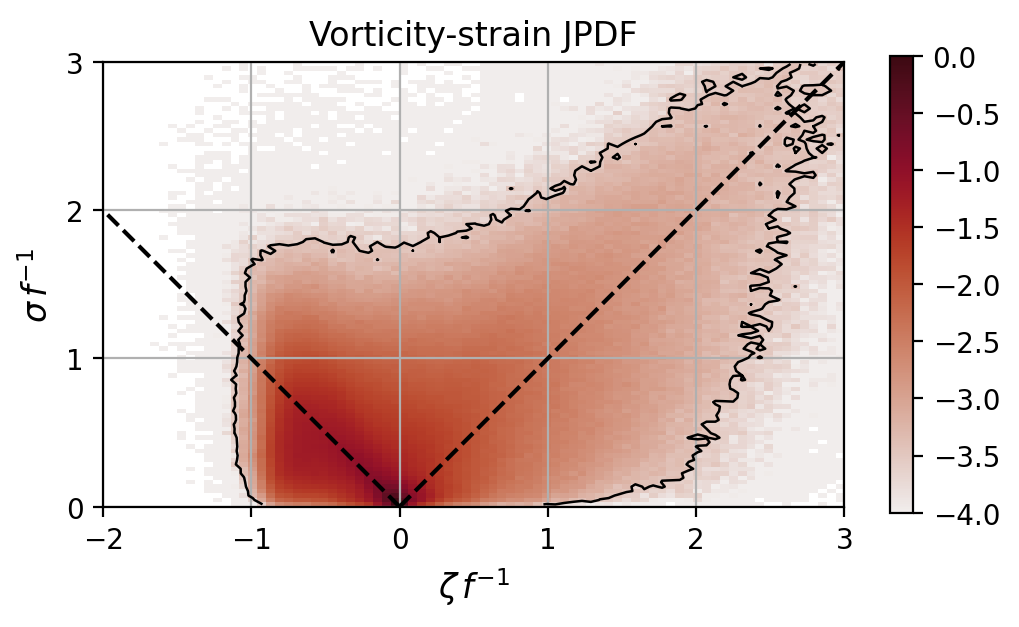

In [16]:
# Plot this to see how it looks

# Make the figure
fig, ax = plt.subplots(1,1,figsize=(5,3),
                    constrained_layout=True,dpi=200)

# Transpose so that vorticity is the x axis, strain the y axis. Colorbar limits 
# are 1e-4, 1. The result 
c = np.log10(zeta_sigma_pdf_peak_eke.T).plot(vmin=-4,vmax=0,cmap=cmo.amp, add_colorbar=False)
fig.colorbar(c)

# Flatten and sort the PDF values
pdf_vals = zeta_sigma_pdf_peak_eke.T.values.flatten()
sorted_vals = np.sort(pdf_vals)[::-1]  # descending order

# Cumulative sum and normalize
cumsum = np.cumsum(sorted_vals)
cumsum /= cumsum[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_peak_eke.zeta_bin, zeta_sigma_pdf_peak_eke.sigma_bin, zeta_sigma_pdf_peak_eke.T,
           levels=[threshold], colors='k', linestyles='-', linewidths=0.9)

# Since we are working with a normalized PDF, above isn't the true 99% contour?
# So we can try recovering the true PDF and calculating the contour from that data. 
# Uncomment this to check that they are close, if not indistinguishable. 
# Rescaled PDF (max = 1)
rescaled_pdf = zeta_sigma_pdf_peak_eke.T.values

# # Recover a true PDF by renormalizing
# pdf = rescaled_pdf / np.sum(rescaled_pdf)  # True PDF now

# # Sort and compute cumulative probability
# sorted_vals = np.sort(pdf.flatten())[::-1]
# cumsum = np.cumsum(sorted_vals)
# threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# # Plot the 99.9% contour
# ax.contour(zeta_sigma_pdf.zeta_bin, zeta_sigma_pdf.sigma_bin, pdf,
#            levels=[threshold], colors='r', linewidths=0.9)

ax.grid(True)
ax.set_aspect(1.0)
ax.plot((0, 3), (0, 3), '--k')
ax.plot((0, -2), (0, 2), '--k')
# ax.plot((0, 0), (0, 3), '--k')
# ax.text(-1.7, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 1.4, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=45)
# ax.text(-1.7, 1.5, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=-45)
# ax.text(-0.2, 2.1, 'strain', horizontalalignment='left', verticalalignment='bottom', rotation=90)
ax.set_yticks([0, 1, 2, 3])
ax.set_xlabel(r'$\zeta\,f^{-1}$', fontsize=12)
ax.set_ylabel(r'$\sigma\,f^{-1}$', fontsize=12)
# ax.set_title('ROMS')
ax.set_title(r'Vorticity-strain JPDF')
ax.set_xlim(-2,3)

**All Time**  

Do the calculations for the full time period

In [17]:
# Slice the data we need to this region and load it
zeta_all_time = ds_ice_u3c4_keps.zeta.isel(ocean_time=time_slice_all, eta_rho=eta_slice_box2,xi_rho=xi_slice).load()
delta_all_time = ds_ice_u3c4_keps.delta.isel(ocean_time=time_slice_all, eta_rho=eta_slice_box2,xi_rho=xi_slice).load()
sigma_all_time = ds_ice_u3c4_keps.sigma.isel(ocean_time=time_slice_all, eta_rho=eta_slice_box2,xi_rho=xi_slice).load()

In [18]:
# Calculate the histogram for vorticity-strain
# (no vertical slicing since looking at surface things)
# Vorticity-strain PDF
zeta_sigma_pdf_all_time = histogram(zeta_all_time, sigma_all_time, block_size=zeta_all_time.ocean_time.size, 
                           bins=[zeta_bins, sigma_bins],
                         density=True).load()
zeta_sigma_pdf_all_time = zeta_sigma_pdf_all_time/zeta_sigma_pdf_all_time.max()

(-2.0, 3.0)

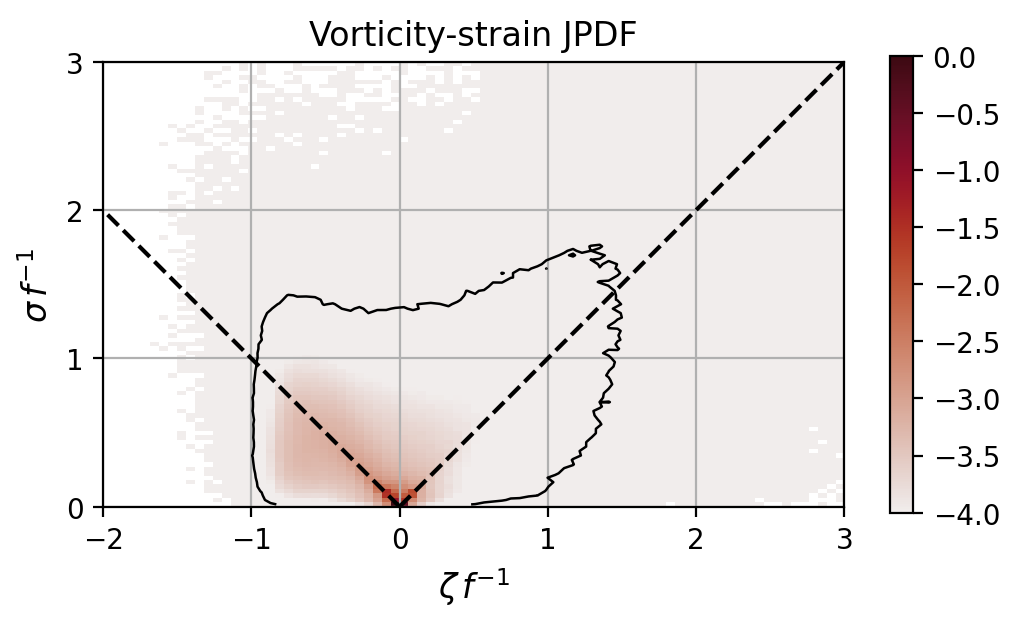

In [19]:
# Plot this to see how it looks

# Make the figure
fig, ax = plt.subplots(1,1,figsize=(5,3),
                    constrained_layout=True,dpi=200)

# Transpose so that vorticity is the x axis, strain the y axis. Colorbar limits 
# are 1e-4, 1. The result 
c = np.log10(zeta_sigma_pdf_all_time.T).plot(vmin=-4,vmax=0,cmap=cmo.amp, add_colorbar=False)
fig.colorbar(c)

# Flatten and sort the PDF values
pdf_vals = zeta_sigma_pdf_all_time.T.values.flatten()
sorted_vals = np.sort(pdf_vals)[::-1]  # descending order

# Cumulative sum and normalize
cumsum = np.cumsum(sorted_vals)
cumsum /= cumsum[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_all_time.zeta_bin, zeta_sigma_pdf_all_time.sigma_bin, zeta_sigma_pdf_all_time.T,
           levels=[threshold], colors='k', linestyles='-', linewidths=0.9)

# Since we are working with a normalized PDF, above isn't the true 99% contour?
# So we can try recovering the true PDF and calculating the contour from that data. 
# Uncomment this to check that they are close, if not indistinguishable. 
# Rescaled PDF (max = 1)
rescaled_pdf = zeta_sigma_pdf_all_time.T.values

# # Recover a true PDF by renormalizing
# pdf = rescaled_pdf / np.sum(rescaled_pdf)  # True PDF now

# # Sort and compute cumulative probability
# sorted_vals = np.sort(pdf.flatten())[::-1]
# cumsum = np.cumsum(sorted_vals)
# threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# # Plot the 99.9% contour
# ax.contour(zeta_sigma_pdf.zeta_bin, zeta_sigma_pdf.sigma_bin, pdf,
#            levels=[threshold], colors='r', linewidths=0.9)

ax.grid(True)
ax.set_aspect(1.0)
ax.plot((0, 3), (0, 3), '--k')
ax.plot((0, -2), (0, 2), '--k')
# ax.plot((0, 0), (0, 3), '--k')
# ax.text(-1.7, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 1.4, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=45)
# ax.text(-1.7, 1.5, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=-45)
# ax.text(-0.2, 2.1, 'strain', horizontalalignment='left', verticalalignment='bottom', rotation=90)
ax.set_yticks([0, 1, 2, 3])
ax.set_xlabel(r'$\zeta\,f^{-1}$', fontsize=12)
ax.set_ylabel(r'$\sigma\,f^{-1}$', fontsize=12)
# ax.set_title('ROMS')
ax.set_title(r'Vorticity-strain JPDF')
ax.set_xlim(-2,3)

**All Ice, Little/No Eddies**  

Do the calculations for a time with little to no eddies/EKE (days 50 - 60)

In [34]:
# Slice the data we need to this region and load it
zeta_full_ice = ds_ice_u3c4_keps.zeta.isel(ocean_time=time_slice_full_ice, eta_rho=eta_slice_box2,xi_rho=xi_slice).load()
delta_full_ice = ds_ice_u3c4_keps.delta.isel(ocean_time=time_slice_full_ice, eta_rho=eta_slice_box2,xi_rho=xi_slice).load()
sigma_full_ice = ds_ice_u3c4_keps.sigma.isel(ocean_time=time_slice_full_ice, eta_rho=eta_slice_box2,xi_rho=xi_slice).load()

In [35]:
# Calculate the histogram for vorticity-strain
# (no vertical slicing since looking at surface things)
# Vorticity-strain PDF
zeta_sigma_pdf_full_ice = histogram(zeta_full_ice, sigma_full_ice, block_size=zeta_full_ice.ocean_time.size, 
                           bins=[zeta_bins, sigma_bins],
                         density=True).load()
zeta_sigma_pdf_full_ice = zeta_sigma_pdf_full_ice/zeta_sigma_pdf_full_ice.max()

(0.0, 0.3)

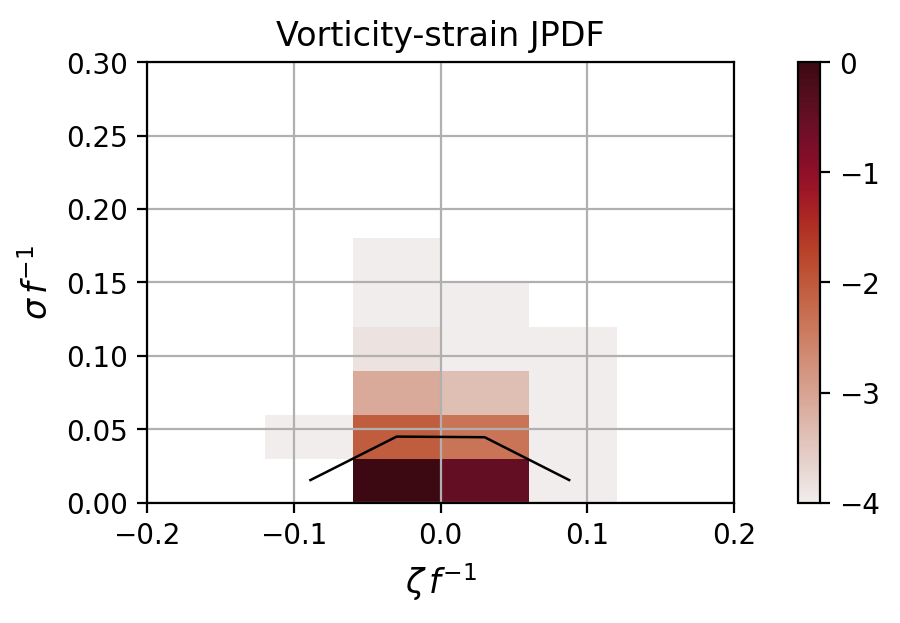

In [44]:
# Plot this to see how it looks

# Make the figure
fig, ax = plt.subplots(1,1,figsize=(5,3),
                    constrained_layout=True,dpi=200)

# Transpose so that vorticity is the x axis, strain the y axis. Colorbar limits 
# are 1e-4, 1. The result 
c = np.log10(zeta_sigma_pdf_full_ice.T).plot(vmin=-4,vmax=0,cmap=cmo.amp, add_colorbar=False)
fig.colorbar(c)

# Flatten and sort the PDF values
pdf_vals = zeta_sigma_pdf_full_ice.T.values.flatten()
sorted_vals = np.sort(pdf_vals)[::-1]  # descending order

# Cumulative sum and normalize
cumsum = np.cumsum(sorted_vals)
cumsum /= cumsum[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_full_ice.zeta_bin, zeta_sigma_pdf_full_ice.sigma_bin, zeta_sigma_pdf_full_ice.T,
           levels=[threshold], colors='k', linestyles='-', linewidths=0.9)

# Since we are working with a normalized PDF, above isn't the true 99% contour?
# So we can try recovering the true PDF and calculating the contour from that data. 
# Uncomment this to check that they are close, if not indistinguishable. 
# Rescaled PDF (max = 1)
rescaled_pdf = zeta_sigma_pdf_full_ice.T.values

# # Recover a true PDF by renormalizing
# pdf = rescaled_pdf / np.sum(rescaled_pdf)  # True PDF now

# # Sort and compute cumulative probability
# sorted_vals = np.sort(pdf.flatten())[::-1]
# cumsum = np.cumsum(sorted_vals)
# threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# # Plot the 99.9% contour
# ax.contour(zeta_sigma_pdf.zeta_bin, zeta_sigma_pdf.sigma_bin, pdf,
#            levels=[threshold], colors='r', linewidths=0.9)

ax.grid(True)
ax.set_aspect(1.0)
#ax.plot((0, 3), (0, 3), '--k')
#ax.plot((0, -2), (0, 2), '--k')
# ax.plot((0, 0), (0, 3), '--k')
# ax.text(-1.7, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 1.4, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=45)
# ax.text(-1.7, 1.5, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=-45)
# ax.text(-0.2, 2.1, 'strain', horizontalalignment='left', verticalalignment='bottom', rotation=90)
#ax.set_yticks([0, 1, 2, 3])
ax.set_xlabel(r'$\zeta\,f^{-1}$', fontsize=12)
ax.set_ylabel(r'$\sigma\,f^{-1}$', fontsize=12)
# ax.set_title('ROMS')
ax.set_title(r'Vorticity-strain JPDF')
ax.set_xlim(-0.2,0.2)
ax.set_ylim(0,0.3)

**Plot the Combined Version**  

Make a version that shows the values for peak EKE time period but includes the line for the 99% for the full time period.

(-2.0, 3.0)

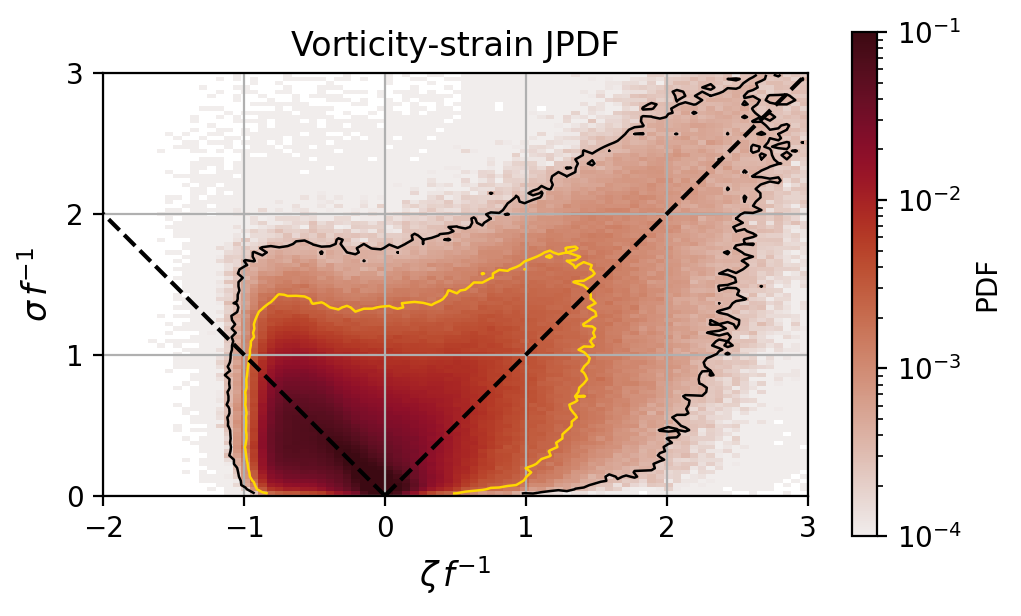

In [31]:
# Same as the other plots but showing peak EKE
# time period and line for 99% for all time

# Make the figure
fig, ax = plt.subplots(1,1,figsize=(5,3),
                    constrained_layout=True,dpi=200)

# Transpose so that vorticity is the x axis, strain the y axis. Colorbar limits 
# are 1e-4, 1. The result 
#c = np.log10(zeta_sigma_pdf_peak_eke.T).plot(vmin=-4,vmax=0,cmap=cmo.amp, add_colorbar=False)
c = zeta_sigma_pdf_peak_eke.T.plot(norm=LogNorm(vmin=1e-4, vmax=1e-1), cmap=cmo.amp, add_colorbar=False)
cbar1 = fig.colorbar(c, format='%.1e', label='PDF')
cbar1.formatter = LogFormatterMathtext(base=10)

# Add line for 99%
# -- Peak EKE --
# Flatten and sort the PDF values
pdf_vals_peak_eke = zeta_sigma_pdf_peak_eke.T.values.flatten()
sorted_vals_peak_eke = np.sort(pdf_vals_peak_eke)[::-1]  # descending order

# Cumulative sum and normalize
cumsum_peak_eke = np.cumsum(sorted_vals_peak_eke)
cumsum_peak_eke /= cumsum_peak_eke[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold_peak_eke = sorted_vals_peak_eke[np.searchsorted(cumsum_peak_eke, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_peak_eke.zeta_bin, zeta_sigma_pdf_peak_eke.sigma_bin, zeta_sigma_pdf_peak_eke.T,
           levels=[threshold_peak_eke], colors='k', linestyles='-', linewidths=0.9)

# -- All Time --
# Flatten and sort the PDF values
pdf_vals_all_time = zeta_sigma_pdf_all_time.T.values.flatten()
sorted_vals_all_time = np.sort(pdf_vals_all_time)[::-1]  # descending order

# Cumulative sum and normalize
cumsum_all_time = np.cumsum(sorted_vals_all_time)
cumsum_all_time /= cumsum_all_time[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold_all_time = sorted_vals_all_time[np.searchsorted(cumsum_all_time, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_all_time.zeta_bin, zeta_sigma_pdf_all_time.sigma_bin, zeta_sigma_pdf_all_time.T,
           levels=[threshold_all_time], colors='gold', linestyles='-', linewidths=0.9)

# Since we are working with a normalized PDF, above isn't the true 99% contour?
# So we can try recovering the true PDF and calculating the contour from that data. 
# Uncomment this to check that they are close, if not indistinguishable. 
# Rescaled PDF (max = 1)
rescaled_pdf = zeta_sigma_pdf_peak_eke.T.values

# # Recover a true PDF by renormalizing
# pdf = rescaled_pdf / np.sum(rescaled_pdf)  # True PDF now

# # Sort and compute cumulative probability
# sorted_vals = np.sort(pdf.flatten())[::-1]
# cumsum = np.cumsum(sorted_vals)
# threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# # Plot the 99.9% contour
# ax.contour(zeta_sigma_pdf.zeta_bin, zeta_sigma_pdf.sigma_bin, pdf,
#            levels=[threshold], colors='r', linewidths=0.9)

ax.grid(True)
ax.set_aspect(1.0)
ax.plot((0, 3), (0, 3), '--k')
ax.plot((0, -2), (0, 2), '--k')
# ax.plot((0, 0), (0, 3), '--k')
# ax.text(-1.7, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 1.4, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=45)
# ax.text(-1.7, 1.5, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=-45)
# ax.text(-0.2, 2.1, 'strain', horizontalalignment='left', verticalalignment='bottom', rotation=90)
ax.set_yticks([0, 1, 2, 3])
ax.set_xlabel(r'$\zeta\,f^{-1}$', fontsize=12)
ax.set_ylabel(r'$\sigma\,f^{-1}$', fontsize=12)
# ax.set_title('ROMS')
ax.set_title(r'Vorticity-strain JPDF')
ax.set_xlim(-2,3)

(-2.0, 3.0)

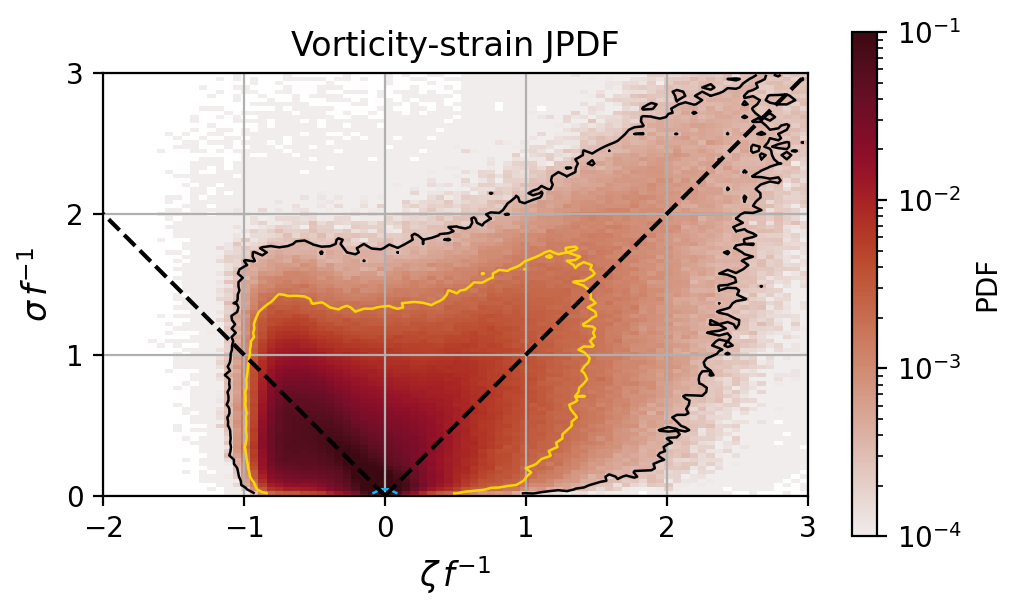

In [45]:
# Make this again including a line for full ice cover
# and little eddy activity

# Make the figure
fig, ax = plt.subplots(1,1,figsize=(5,3),
                    constrained_layout=True,dpi=200)

# Transpose so that vorticity is the x axis, strain the y axis. Colorbar limits 
# are 1e-4, 1. The result 
#c = np.log10(zeta_sigma_pdf_peak_eke.T).plot(vmin=-4,vmax=0,cmap=cmo.amp, add_colorbar=False)
c = zeta_sigma_pdf_peak_eke.T.plot(norm=LogNorm(vmin=1e-4, vmax=1e-1), cmap=cmo.amp, add_colorbar=False)
cbar1 = fig.colorbar(c, format='%.1e', label='PDF')
cbar1.formatter = LogFormatterMathtext(base=10)

# Add line for 99%
# -- Peak EKE --
# Flatten and sort the PDF values
pdf_vals_peak_eke = zeta_sigma_pdf_peak_eke.T.values.flatten()
sorted_vals_peak_eke = np.sort(pdf_vals_peak_eke)[::-1]  # descending order

# Cumulative sum and normalize
cumsum_peak_eke = np.cumsum(sorted_vals_peak_eke)
cumsum_peak_eke /= cumsum_peak_eke[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold_peak_eke = sorted_vals_peak_eke[np.searchsorted(cumsum_peak_eke, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_peak_eke.zeta_bin, zeta_sigma_pdf_peak_eke.sigma_bin, zeta_sigma_pdf_peak_eke.T,
           levels=[threshold_peak_eke], colors='k', linestyles='-', linewidths=0.9)

# -- All Time --
# Flatten and sort the PDF values
pdf_vals_all_time = zeta_sigma_pdf_all_time.T.values.flatten()
sorted_vals_all_time = np.sort(pdf_vals_all_time)[::-1]  # descending order

# Cumulative sum and normalize
cumsum_all_time = np.cumsum(sorted_vals_all_time)
cumsum_all_time /= cumsum_all_time[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold_all_time = sorted_vals_all_time[np.searchsorted(cumsum_all_time, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_all_time.zeta_bin, zeta_sigma_pdf_all_time.sigma_bin, zeta_sigma_pdf_all_time.T,
           levels=[threshold_all_time], colors='gold', linestyles='-', linewidths=0.9)

# -- Ice Time --
# Flatten and sort the PDF values
pdf_vals_full_ice = zeta_sigma_pdf_full_ice.T.values.flatten()
sorted_vals_full_ice = np.sort(pdf_vals_full_ice)[::-1]  # descending order

# Cumulative sum and normalize
cumsum_full_ice = np.cumsum(sorted_vals_full_ice)
cumsum_full_ice /= cumsum_full_ice[-1]  # normalize to 1

# Find the value at which 99.9% of the mass is enclosed
threshold_full_ice = sorted_vals_full_ice[np.searchsorted(cumsum_full_ice, 0.99)]

# Now plot the contour at that threshold
ax.contour(zeta_sigma_pdf_full_ice.zeta_bin, zeta_sigma_pdf_full_ice.sigma_bin, zeta_sigma_pdf_full_ice.T,
           levels=[threshold_full_ice], colors='deepskyblue', linestyles='-', linewidths=0.9)

# Since we are working with a normalized PDF, above isn't the true 99% contour?
# So we can try recovering the true PDF and calculating the contour from that data. 
# Uncomment this to check that they are close, if not indistinguishable. 
# Rescaled PDF (max = 1)
rescaled_pdf = zeta_sigma_pdf_peak_eke.T.values

# # Recover a true PDF by renormalizing
# pdf = rescaled_pdf / np.sum(rescaled_pdf)  # True PDF now

# # Sort and compute cumulative probability
# sorted_vals = np.sort(pdf.flatten())[::-1]
# cumsum = np.cumsum(sorted_vals)
# threshold = sorted_vals[np.searchsorted(cumsum, 0.99)]

# # Plot the 99.9% contour
# ax.contour(zeta_sigma_pdf.zeta_bin, zeta_sigma_pdf.sigma_bin, pdf,
#            levels=[threshold], colors='r', linewidths=0.9)

ax.grid(True)
ax.set_aspect(1.0)
ax.plot((0, 3), (0, 3), '--k')
ax.plot((0, -2), (0, 2), '--k')
# ax.plot((0, 0), (0, 3), '--k')
# ax.text(-1.7, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 0.05, 'eddy', horizontalalignment='left', verticalalignment='bottom')
# ax.text(1.2, 1.4, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=45)
# ax.text(-1.7, 1.5, 'shear', horizontalalignment='left', verticalalignment='bottom', rotation=-45)
# ax.text(-0.2, 2.1, 'strain', horizontalalignment='left', verticalalignment='bottom', rotation=90)
ax.set_yticks([0, 1, 2, 3])
ax.set_xlabel(r'$\zeta\,f^{-1}$', fontsize=12)
ax.set_ylabel(r'$\sigma\,f^{-1}$', fontsize=12)
# ax.set_title('ROMS')
ax.set_title(r'Vorticity-strain JPDF')
ax.set_xlim(-2,3)

### Useful Things from Dylan's GitHub for Later

In [ ]:
zeta = ds.zeta.sel(ocean_time=tslice).isel(eta_rho=etaslice,xi_rho=xislice).load()
delta = ds.delta.sel(ocean_time=tslice).isel(eta_rho=etaslice,xi_rho=xislice).load()
sigma = ds.sigma.sel(ocean_time=tslice).isel(eta_rho=etaslice,xi_rho=xislice).load()

In [ ]:
# Bin widths for PDFs. These may need tuning
zetabins = np.linspace(-3,3,101)
deltabins = np.linspace(-3,2,101)
sigmabins = np.linspace(0,3,101) 

In [ ]:
zetapdf = histogram(zeta,bins=[zetabins],density=True).load()
# Normalize by max value so the max value is one. Optional but not required. 
zetapdf = zetapdf/zetapdf.max() 

In [ ]:
# Divergence PDF
deltapdf = histogram(delta,bins=[deltabins],density=True).load()
deltapdf = deltapdf/deltapdf.max()

# Strain PDF
sigmapdf = histogram(sigma,bins=[sigmabins],density=True).load()
sigmapdf = sigmapdf/sigmapdf.max()

# Vorticity-strain PDF
zetasgimapdf = histogram(zeta,sigma, bins=[zetabins,sigmabins],
                         density=True).load()
zetasgimapdf = zetasgimapdf/zetasgimapdf.max()